# 05 - Four classes with softmax

Phase 3.

In Phase 2 we had two classes, N and V, and they look very different. Now we use all
four classes:

- **N** normal
- **S** starts early, from the top of the heart. **The shape looks like a normal beat.**
- **V** starts in the bottom of the heart, wide shape
- **F** two beats at the same time, shape is in the middle

Only three things change in the code:

1. the last layer becomes **softmax with 4 outputs** instead of sigmoid with 1
2. the loss becomes **categorical cross entropy**
3. the labels become **one hot**

The model itself does not change. That is the point of writing it as a loop over
layers.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from ecg.config import Config
from ecg.data import load_split, class_names
from ecg.metrics import report, macro_f1, per_class, confusion_matrix, majority_baseline
from ecg import plots

## 1. The new floor

With four classes the lazy model still says "normal" every time. Accuracy stays
high, but macro-F1 drops, because now **three** classes get an F1 of zero instead
of one.

In [2]:
Xdv, ydv, rec_dv = load_split("dev", classes="all", columns=True)
counts = np.bincount(ydv.ravel(), minlength=4)
for name, n in zip(class_names("all"), counts):
    print(name, n)

print()
print("IF WE ALWAYS SAY NORMAL:")
print(report(ydv, np.zeros_like(ydv), class_names("all")))

N 9430
S 218
V 818
F 32

IF WE ALWAYS SAY NORMAL:
 class     prec   recall       f1  support
     N    0.898    1.000    0.946     9430
     S    0.000    0.000    0.000      218
     V    0.000    0.000    0.000      818
     F    0.000    0.000    0.000       32

  accuracy  0.8983   (baseline 0.8983)
  macro-F1  0.2366


**The floor is macro-F1 0.2366.** That is what we must beat.

## 2. Check the gradient again

We changed the last layer and the loss. The maths of the backward pass is different
now, even if the final formula looks the same. So we check again before we believe
any number.

In [3]:
from ecg.init import initialize_parameters
from ecg.model import forward, backward
from ecg.gradcheck import gradient_check

rng = np.random.default_rng(0)
X_small = rng.standard_normal((8, 6))
Y_small = np.zeros((4, 6))
Y_small[rng.integers(0, 4, 6), np.arange(6)] = 1.0

for dims in [[8, 4], [8, 5, 4], [8, 5, 3, 4]]:
    p = initialize_parameters(dims, "he", seed=1)
    AL, cache = forward(X_small, p, "tanh", "softmax")
    grads = backward(AL, Y_small, cache, p, "tanh", "softmax")
    print(str(dims) + " ->", end=" ")
    gradient_check(p, grads, X_small, Y_small, "tanh", "softmax")

[8, 4] -> gradient check PASS, relative error 2.7733376734623766e-09
[8, 5, 4] -> gradient check PASS, relative error 5.2936551909751e-09
[8, 5, 3, 4] -> 

gradient check PASS, relative error 4.065414891847036e-09


Good. `dZL = AL - Y` is true for softmax too.

### A second small check

A model that knows nothing gives every class the same probability, so the first loss
should be `ln(4) = 1.386`. If it is not, then our one hot labels or our class axis
are wrong.

In [4]:
from ecg.losses import compute_loss
from ecg.train import prepare_labels

Xtr, ytr, _ = load_split("train", "waveform+rr", "all", columns=True)
Ytr = prepare_labels(ytr, 4)

p = initialize_parameters([254, 16, 4], "random", seed=1)
AL, cache = forward(Xtr, p, "tanh", "softmax", training=False)
loss = compute_loss(AL, Ytr, "categorical_crossentropy", ZL=cache["Z2"])
print("first loss   %.5f" % loss)
print("ln(4)        %.5f" % np.log(4))

first loss   1.38752
ln(4)        1.38629


## 3. The big question: do the timing features help?

This is the main idea of the whole project.

Class S has **the same shape** as a normal beat. The only difference is that it
arrives **early**. The 250 waveform numbers cannot show "early", because they only
look at one beat. So we also built 4 timing numbers.

**Our guess before the experiment: the timing features should make S recall go up.**

The runs are already in `results/results.csv`. Here is the summary.

In [5]:
# HOW THE RUNS WERE MADE (about 2 minutes each group, so they are turned off here)
#
# from dataclasses import replace
# from ecg.train import train
# base = Config(classes="all", output_activation="softmax", optimizer="gd",
#               hidden_dims=(16,), hidden_activation="tanh", init="he",
#               learning_rate=0.1, batch_size=64, epochs=30, phase="3")
# for feats in ["waveform", "waveform+rr", "rr"]:
#     for seed in [1, 2, 3]:
#         train(replace(base, features=feats, seed=seed), verbose=False)

rows = [("timing only (rr)",      4, 0.4802, 0.532, 0.500),
        ("shape only (waveform)", 250, 0.2779, 0.067, 0.689),
        ("both, raw (254)",       254, 0.3145, 0.028, 0.697),
        ("both, standardised",    254, 0.3655, 0.171, 0.652)]

print("%-24s %7s %10s %10s %10s" % ("input", "n_feat", "macro-F1", "S recall", "V recall"))
for name, n, f1, s, v in rows:
    print("%-24s %7d %10.4f %10.3f %10.3f" % (name, n, f1, s, v))

input                     n_feat   macro-F1   S recall   V recall
timing only (rr)               4     0.4802      0.532      0.500
shape only (waveform)        250     0.2779      0.067      0.689
both, raw (254)              254     0.3145      0.028      0.697
both, standardised           254     0.3655      0.171      0.652


## 4. The result is not what we expected

Read the table again slowly.

- **4 timing numbers alone give S recall 0.53.** With only 4 features!
- **250 shape numbers give S recall 0.07.** Almost nothing, as we thought.
- **Putting them together gives 0.03.** This is **worse than both**.

So the timing signal is real and strong. But when we put the 4 timing numbers next
to the 250 shape numbers, the model stops using them.

### Why?

The two groups of numbers do not have the same size.

In [6]:
X, y, _ = load_split("train", features="waveform+rr", classes="all", columns=True)
wave, rr = X[:250], X[250:]

print("total variance in the 250 waveform features: %.1f" % (wave.std(axis=1)**2).sum())
print("total variance in the 4 rr features        : %.3f" % (rr.std(axis=1)**2).sum())
print("ratio: %.0f times bigger" % ((wave.std(axis=1)**2).sum() / (rr.std(axis=1)**2).sum()))

rng = np.random.default_rng(0)
W = rng.standard_normal((16, 254)) * np.sqrt(2.0 / 254)
print()
print("what one hidden unit hears at the start:")
print("   from the waveform: std %.4f" % (W[:, :250] @ wave[:, :2000]).std())
print("   from the timing  : std %.4f" % (W[:, 250:] @ rr[:, :2000]).std())

total variance in the 250 waveform features: 108.9
total variance in the 4 rr features        : 0.101


ratio: 1079 times bigger

what one hidden unit hears at the start:
   from the waveform: std 1.7515
   from the timing  : std 0.1368


The waveform block is about **1000 times louder**. Before training even starts, the
hidden units almost cannot hear the timing numbers. And plain gradient descent uses
**the same step size for every weight**, so the small ones stay small.

It is like putting 4 people who know the answer in a room with 250 people who are
shouting.

### One fix: make every feature the same size

If we scale every feature to mean 0 and std 1, S recall goes from **0.03 to 0.17**.
Better, but still far from the 0.53 that the timing numbers get alone. So the size
of the features is only one part of the problem. The other part is probably the
optimiser, and that is Phase 4.

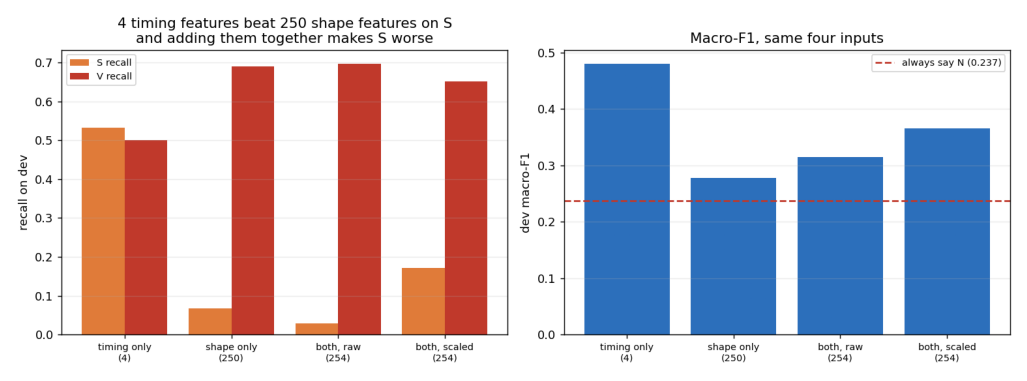

In [7]:
fig = plt.imread("../results/figures/phase3_features.png")
plt.figure(figsize=(13, 5)); plt.imshow(fig); plt.axis("off"); plt.show()

## 5. Where the mistakes are

The confusion matrix shows exactly what the model does wrong.

 class     prec   recall       f1  support
     N    0.953    0.957    0.955     9430
     S    0.333    0.018    0.035      218
     V    0.735    0.689    0.712      818
     F    0.000    0.000    0.000       32

  accuracy  0.9139   (baseline 0.8983)
  macro-F1  0.4254


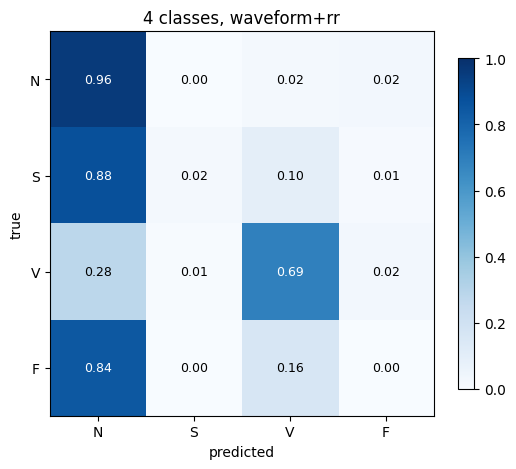

In [8]:
# we train one model here, it takes about 20 seconds
from ecg.train import train

cfg = Config(classes="all", output_activation="softmax", optimizer="gd",
             features="waveform+rr", hidden_dims=(16,), hidden_activation="tanh",
             init="he", learning_rate=0.1, batch_size=64, epochs=30, seed=3,
             phase="3-notebook", note="the run shown in the notebook")
out = train(cfg, verbose=False, log=False)
pred = out["dev_pred"]

print(report(ydv, pred, class_names("all")))
cm = confusion_matrix(ydv.ravel(), pred, 4)
fig = plots.confusion(cm, class_names("all"), title="4 classes, waveform+rr")
plt.show()

Look at the row for **S**. There are 218 real S beats, and **191 of them are called
N**. The model says "this is a normal beat", which is exactly what we predicted from
the shape of the wave: an S beat *looks* normal.

Look at the row for **F**. Every single one is wrong. There are only 382 F beats in
train, and 372 of them come from **one patient**. The model never really learned
this class, and dev only has 32 of them, so we cannot measure it well either.

## 6. What we learned

1. **We beat the floor.** 0.2366 -> 0.4254. So the model learned something real.
2. **Our guess was right, but the experiment was hiding it.** The timing features do
   carry the answer for class S, we proved it by using them alone. They fail only
   when they sit next to 250 much louder features.
3. **Two "independent" experiments were not independent.** We planned to test the
   features (axis 9) and the class imbalance (axis 8) separately in Phase 4. But
   without class weights the model almost never says S, so the feature test could
   not measure anything. We had to run both together to see the truth.
4. **Class F is not really learnable here.** This is a limit of the data, not of the
   model.

The most useful thing for Phase 4 is now clear: **try scaling the features, and try
Adam.** Adam changes the step size for each weight on its own, so it should be able
to hear the quiet features.